In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import norm
import scipy
np.random.seed(809)

# Create a random outcome variable (from the normal distribution)

In [2]:
date_rng = pd.date_range(start='1/1/2018', end='1/08/2018', freq='H')
df = pd.DataFrame(date_rng, columns=['date'])
df['y'] = np.random.normal(10, 10, size=(len(date_rng))) # mean=10, standard deviation=10
df

,date,y
0,2018-01-01 00:00:00,10.580940
1,2018-01-01 01:00:00,8.706336
2,2018-01-01 02:00:00,16.215551
3,2018-01-01 03:00:00,10.558374
4,2018-01-01 04:00:00,1.002296
...,...,...
164,2018-01-07 20:00:00,24.846091
165,2018-01-07 21:00:00,9.280818
166,2018-01-07 22:00:00,25.294808
167,2018-01-07 23:00:00,6.660495


# Create 100 random independent variables

In [3]:
for x in range(1, 101):
    df['x_'+str(x)] = np.random.normal(10, 10, size=(len(date_rng)))
df

,date,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,...,x_91,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100
0,2018-01-01 00:00:00,10.580940,6.924164,10.739348,7.517994,0.714640,-15.832233,18.234232,22.832766,14.632361,...,17.816591,-9.671880,-0.338718,0.582550,10.304509,-5.928453,7.209920,-4.044284,-5.354726,10.323206
1,2018-01-01 01:00:00,8.706336,6.563708,25.307331,22.723691,17.830288,13.910235,19.556706,-8.342406,8.480840,...,9.425531,-4.922766,3.223513,11.759829,15.819940,11.588406,16.841934,22.460818,11.284738,4.627334
2,2018-01-01 02:00:00,16.215551,12.990696,2.941114,12.606864,26.081429,32.915954,13.424834,26.995261,30.442949,...,24.131801,4.524748,14.079444,4.489741,29.070127,-5.666432,22.701471,15.588079,7.705848,12.624507
3,2018-01-01 03:00:00,10.558374,-3.018864,10.684139,12.929467,23.063026,8.520099,4.529080,-7.954920,-4.881092,...,21.253918,17.590765,3.062414,10.703607,2.909368,30.614690,12.455607,-3.131508,6.097825,24.019109
4,2018-01-01 04:00:00,1.002296,8.733216,1.256444,19.030755,6.961442,5.975020,18.001091,7.507429,3.330203,...,9.617241,8.477832,14.160974,6.185773,-1.678576,14.753665,11.512459,0.733279,20.067947,36.621940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,2018-01-07 20:00:00,24.846091,18.201752,7.620520,11.482962,-4.845149,15.376514,18.116811,34.293986,15.791518,...,6.542716,-0.994103,5.981226,4.018929,2.818748,15.121932,12.706603,12.390569,25.170538,-12.203541
165,2018-01-07 21:00:00,9.280818,2.153762,12.138148,5.347870,10.152349,0.820839,-8.447612,0.216334,20.260018,...,8.327651,1.784528,-23.602155,2.308933,19.491591,-12.008716,-2.637568,13.352339,26.496966,22.314786
166,2018-01-07 22:00:00,25.294808,22.010159,27.791319,-2.203400,16.022171,-4.882677,9.245596,36.150095,0.782485,...,9.892761,11.474620,21.497405,14.365217,11.458261,9.426402,13.179949,9.799391,7.537396,2.408736
167,2018-01-07 23:00:00,6.660495,4.375230,-1.042451,13.264791,16.129164,8.174830,7.800429,16.733016,10.330864,...,14.896838,27.067303,2.722777,20.890881,6.378867,2.379580,5.999913,5.675093,13.983727,19.314009


# Run the regressions

In [4]:
results = {}
tvalues= {}

for i in tqdm(range(1, 101)):
    
    formula = 'y ~ x_'+str(i)
    mod = smf.ols(formula=formula, data=df)
    res = mod.fit()
    
    results['x_'+str(i)] = res.summary()
    tvalues['x_'+str(i)] = res.tvalues['x_'+str(i)]

  0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
#Example
results['x_2']

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                   0.06099
Date:                Thu, 16 Feb 2023   Prob (F-statistic):              0.805
Time:                        13:19:11   Log-Likelihood:                -623.91
No. Observations:                 169   AIC:                             1252.
Df Residuals:                     167   BIC:                             1258.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.2672      1.035      9.916      0.000       8.223      12.311
x_2           -0.0185      0.075     -0.247      0.805      -0.166       0.129
==============================================================================
Omnibus:                        1.305   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.521   Jarque-Bera (JB):                1.400
Skew:                          -0.192   Prob(JB):                        0.497
Kurtosis:                       2.775   Cond. No.                         19.2
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Data mining: some variables appear significant

In [6]:
over_95 = [key for key, tvalue in tvalues.items() if np.abs(tvalue)>=1.96]
print('Number of variables with a t-stat over 1.96:', str(len(over_95)))

Number of variables with a t-stat over 1.96: 3


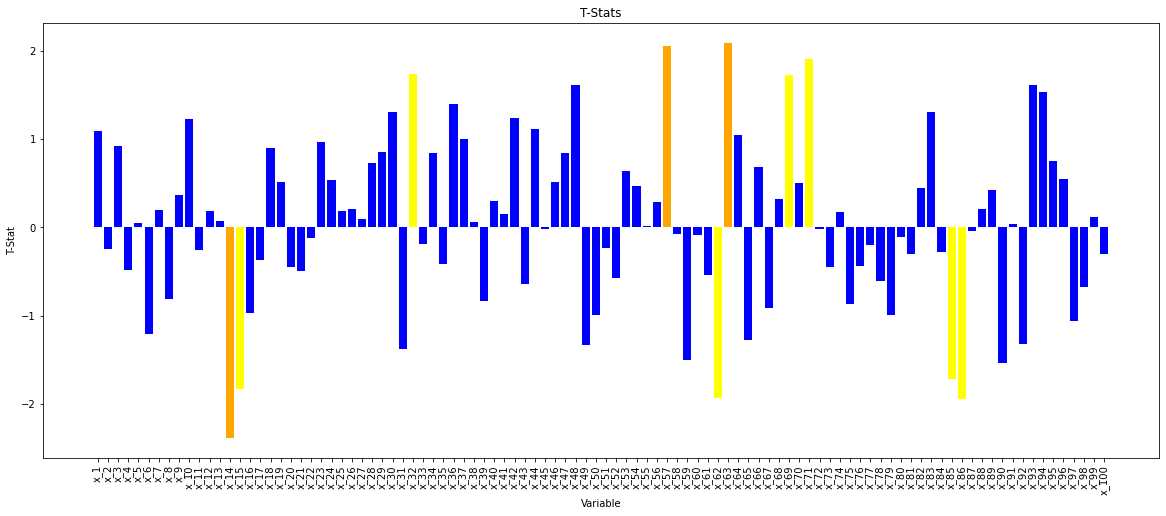

In [7]:
colors=[]
for key, value in tvalues.items():
    if np.abs(value)>=2.58: colors.append('red') # 99% significant
    elif np.abs(value)>=1.96:colors.append('orange') # 95% significant
    elif np.abs(value)>=1.64: colors.append('yellow')
    else: colors.append('blue')

fig, ax= plt.subplots(figsize = (20,8))
ax.bar(['x_'+str(i) for i in range(1,101)] , tvalues.values(), color=colors)
ax.set_xlabel('Variable')
ax.set_ylabel('T-Stat')
ax.set_title('T-Stats')
plt.xticks(rotation=90)
plt.show()

# Which value should we use?

## For 1 test:

If we run 1 test, the probability of seeing a t-stat of more than 1.96 is: 

P = 1 - Probability T-stat<1.96


In [8]:
t_stat = 1.96
P = 1-norm.cdf(t_stat)
print('The probability is: '+'{0:.2f}'.format(P*100) +"%")

The probability is: 2.50%


## For 100 tests:

If we run 100 tests, the probability of seeing a t-stat of more than 1.96 is:

$$P = 1 - P(\text{All T-stats}<1.96)$$

And since the varaibles are uncorrelated:
$$P = 1 - \big(P(\text{T-stat}<1.96)\big)^{100} $$



In [9]:
def return_proba(t_stat, nb_uncorrelated_tests):
    p_all_tstats_below_thres = norm.cdf(t_stat)**nb_uncorrelated_tests
    probability = 1-p_all_tstats_below_thres
    p_per_cent = np.round(probability*100, 2)
    print(f'- If we run {nb_uncorrelated_tests} tests, the probability is of seing T-stat over {t_stat} is {p_per_cent}%')
    return probability

p = return_proba(t_stat=1.96, nb_uncorrelated_tests=100)
p = return_proba(t_stat=2.58, nb_uncorrelated_tests=100)

# From the class
p = return_proba(t_stat=3.07, nb_uncorrelated_tests=650)

- If we run 100 tests, the probability is of seing T-stat over 1.96 is 92.05%
- If we run 100 tests, the probability is of seing T-stat over 2.58 is 39.06%
- If we run 650 tests, the probability is of seing T-stat over 3.07 is 50.15%


### If the variables are correlated:
In the case of two variables $A$ and $B$. We want the probaility that both $A$ and $B$ over 1.96. From Bayes:

\begin{equation*}
    P(AnB) = P(B|A)P(A) 
\end{equation*}
We then need $P(B|A)$

If we let $1_A$ be the indicator random variable that event $A$ occurs (i.e variable $A$ over 1.96), the correlation between $A$ and $B$ is:

\begin{equation*}
\rho_{A,B} = \frac{E(1_A 1_B) -E(1_A)E(1_B)}{\sigma_{1_A}\sigma_{1_B}} = \frac{P(AnB) - P(A)P(B)}{\sqrt{P(A)[1-P(A)]P(B)[1-P(B)]}}
\end{equation*}
Then:
\begin{equation*}
    P(B|A) = P(B) + \rho_{A,B} \sqrt{\frac{P(B)}{P(A)}(1-P(A))(1-P(B))}
\end{equation*}

And:
\begin{equation*}
    P(AnB) = P(A)P(B) + \rho_{A,B} \sqrt{P(B)(1-P(A))(1-P(B))}
\end{equation*}


## T-stat for 100 tests:

Which value should we use for 5% significance then? 

For a 2 sided t-test, we want the probability to be 2.5% on each sides: 

We then solve the previous equation for the t-stat. We want $x$ such that:

$$2.5\% = 1 - \big(P(\text{T-stat}<x)\big)^{100} $$

$$ P(\text{T-stat}<x) = (1-2.5\%)^{1/100} $$

We then just need the Percent Point Function. 

In [10]:
significance_level= 5/100
nb_uncorrelated_tests = 100

def return_t_stat(significance_level, nb_uncorrelated_tests):
    percentage = (1-significance_level/2)**(1/nb_uncorrelated_tests)
    # We call the percent point function to get the value from the Normal Distribution
    t_stat = np.round(norm.ppf(percentage), 2)
    print(f'If we run {nb_uncorrelated_tests} tests, for a significance of {significance_level} we need the t-stat to be {t_stat}')
    return t_stat

t_stat = return_t_stat(significance_level, nb_uncorrelated_tests)

If we run 100 tests, for a significance of 0.05 we need the t-stat to be 3.48


# Goign back to the regressions:

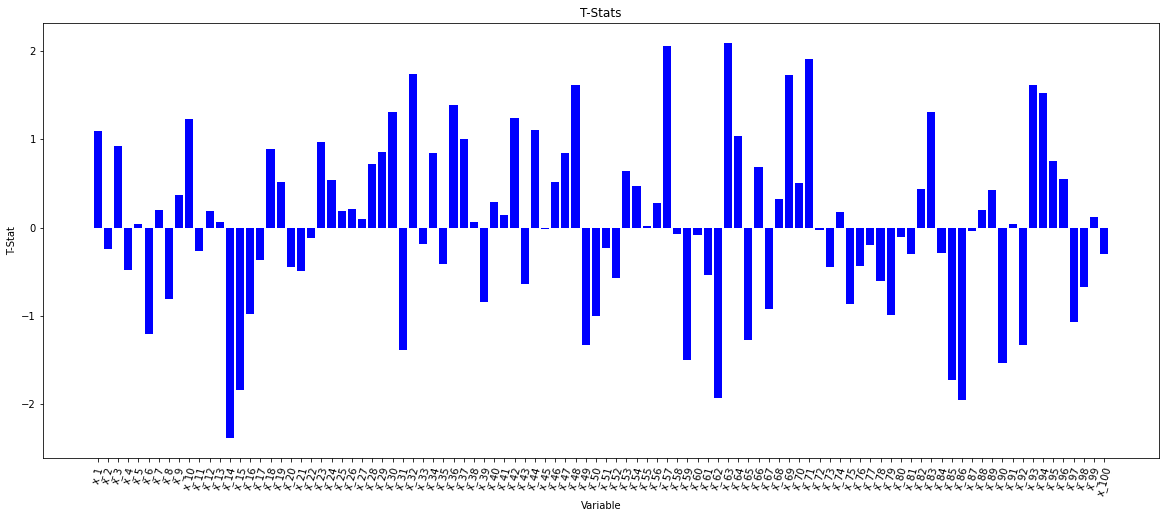

In [11]:
colors=[]
for key, value in tvalues.items():
    if np.abs(value)>=t_stat: colors.append('red') #Using the new t-stat
    else: colors.append('blue')

fig, ax= plt.subplots(figsize = (20,8))
ax.bar(['x_'+str(i) for i in range(1,101)] , tvalues.values(), color=colors)
ax.set_xlabel('Variable')
ax.set_ylabel('T-Stat')
ax.set_title('T-Stats')
plt.xticks(rotation=75)
plt.show()